In [6]:
import DTRGym
import gymnasium as gym
import numpy as np
import os
import sys
import pickle as pkl
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
import torch
import matplotlib.pyplot as plt
import argparse
import csv
from gymnasium.core import RewardWrapper
from scipy import stats
from flow_matching.solver import ODESolver
from torch import nn, Tensor
from flow_matching.utils import ModelWrapper
import pandas as pd
import time

/home/azureuser/miniconda/envs/hti_env/lib/python3.10/site-packages/gym/__init__.py:20: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if distutils.version.LooseVersion(numpy.__version__) < distutils.version.LooseVersion('1.10.4'):
/home/azureuser/miniconda/envs/hti_env/lib/python3.10/site-packages/gym/envs/registration.py:2: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources
/home/azureuser/miniconda/envs/hti_env/lib/python3.10/site-packages/pkg_resources/__init__.py:2871: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('mpl_toolkits')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(pkg)


In [12]:
def print_results(results, name):
    mean = np.mean(results)
    std = np.std(results)
    ci = std / np.sqrt(len(results))
    print(f"{name}: {mean:.3f} ± {ci:.3f}")

device = 'cuda'

# Cancer

In [19]:
sys.path.append('../NLOT')
AGENT_PATH_0 = "policies/ppo_ghaffari_cancer_model__0.zip"
AGENT_PATH_1 = "policies/ppo_ghaffari_cancer_model__100.zip"
AGENT_PATH_2 = "policies/ppo_ghaffari_cancer_model__200.zip"
AGENT_PATH_3 = "policies/ppo_ghaffari_cancer_model__300.zip"
AGENT_PATH_4 = "policies/ppo_ghaffari_cancer_model__400.zip"
AGENT_PATH_5 = "policies/ppo_ghaffari_cancer_model__500.zip"
AGENT_PATH_6 = "policies/ppo_ghaffari_cancer_model__600.zip"
AGENT_PATH_7 = "policies/ppo_ghaffari_cancer_model__700.zip"
AGENT_PATH_8 = "policies/ppo_ghaffari_cancer_model__800.zip"
AGENT_PATH_9 = "policies/ppo_ghaffari_cancer_model__900.zip"
AGENT_PATH_10 = "policies/ppo_ghaffari_cancer_model__1000.zip"
AGENT_NAME = "single_agent_eval"
ENV_NAME = 'GhaffariCancerEnv-continuous'
NUM_EVAL_EPISODES = 1
LAMBDA_VALUES = [0.1, 0.2, 0.3, 0.4, 0.6, 0.7, 0.8, 0.9]
device = "cuda:0"

In [23]:
# Activation class
class Swish(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x: Tensor) -> Tensor: 
        return torch.sigmoid(x) * x

# Model class
class MLP(nn.Module):
    def __init__(self, input_dim: int = 2, time_dim: int = 1, hidden_dim: int = 128, cond_dim: int = 1):
        super().__init__()
        
        self.input_dim = input_dim
        self.time_dim = time_dim
        self.hidden_dim = hidden_dim
        self.cond_dim = cond_dim

        self.main = nn.Sequential(
            nn.Linear(input_dim+time_dim+cond_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, input_dim),
            )
    

    def forward(self, x: Tensor, t: Tensor, cond: Tensor) -> Tensor:
        sz = x.size()
        x = x.reshape(-1, self.input_dim)
        t = t.reshape(-1, self.time_dim).float()
        cond = cond.reshape(-1, self.cond_dim).float()

        t = t.reshape(-1, 1).expand(x.shape[0], 1)
        h = torch.cat([x, t, cond], dim=1)
        output = self.main(h)
        
        return output.reshape(*sz)

class WrappedModel(ModelWrapper):
    def forward(self, x: torch.Tensor, t: torch.Tensor, cond: torch.Tensor, **extras):
        return self.model(x, t, cond)

In [24]:
class Swish(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x: Tensor) -> Tensor: 
        return torch.sigmoid(x) * x

# Model class with FiLM conditioning - ONLY on first layer
class FiLMMLP(nn.Module):
    def __init__(self, input_dim: int = 2, time_dim: int = 1, hidden_dim: int = 64, cond_dim: int = 7):
        super().__init__()
        
        self.input_dim = input_dim
        self.time_dim = time_dim
        self.hidden_dim = hidden_dim
        self.cond_dim = cond_dim
        
        # Main network layers
        self.input_layer = nn.Linear(input_dim + time_dim, hidden_dim)
        self.hidden_layers = nn.ModuleList([
            nn.Linear(hidden_dim, hidden_dim) for _ in range(3)
        ])
        self.output_layer = nn.Linear(hidden_dim, input_dim)
        
        self.activation = Swish()
        
        # FiLM generator network - ONLY for first layer
        self.film_generator = nn.Sequential(
            nn.Linear(cond_dim, hidden_dim),
            self.activation,
            nn.Linear(hidden_dim, hidden_dim * 2)  # Only gamma and beta for first layer
        )
        
    def forward(self, x: Tensor, t: Tensor, cond: Tensor) -> Tensor:
        sz = x.size()
        x = x.reshape(-1, self.input_dim)
        t = t.reshape(-1, self.time_dim).float()
        cond = cond.reshape(-1, self.cond_dim).float()

        # Expand time to match batch size
        t = t.reshape(-1, 1).expand(x.shape[0], 1)
        
        # Generate FiLM parameters from condition - only for first layer
        film_params = self.film_generator(cond)
        gamma = film_params[:, :self.hidden_dim]  # First half
        beta = film_params[:, self.hidden_dim:]   # Second half

        # Main forward pass
        h = torch.cat([x, t], dim=1)
        
        # Input layer with FiLM conditioning
        h = self.input_layer(h)
        h = gamma * h + beta  # Apply FiLM only here
        h = self.activation(h)
        
        # Hidden layers WITHOUT FiLM conditioning
        for layer in self.hidden_layers:
            h = layer(h)
            h = self.activation(h)
            
        # Output layer
        output = self.output_layer(h)
        
        return output.reshape(*sz)

In [20]:
class CustomRewardWrapper(RewardWrapper):
    def __init__(self, env, lambda_nk: float = 0.5):
        super().__init__(env)
        self.lambda_nk = lambda_nk
        self.init_obs = None

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self.init_obs = np.array(obs, copy=True)
        return obs, info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)

        if self.init_obs is not None:
            N_p  = obs[1]
            N_s  = obs[5]
            N_p0 = self.init_obs[1]
            N_s0 = self.init_obs[5]
            N  = max(np.e,  N_p  + N_s)
            N0 = max(np.e,  N_p0 + N_s0)
            logN, logN0 = np.log(N), np.log(N0)
            nk_penalty = -np.abs(logN / logN0 - 1)
            reward = reward + self.lambda_nk * nk_penalty

        return obs, reward, terminated, truncated, info

In [26]:
def flow_forward(action, obs, lambda_val, cfm_models):
    """
    Uses the trained CFM model to push actions forward to target lambda.

    cfm_models is a dict, with key as the time of the end point, and value as the CFM model.
    """
    time_points = list(cfm_models.keys())
    current_action = action.copy()
    t_low = 0.1
    step_size = 0.01

    if lambda_val <= 0:
        return action

    for k in range(len(time_points)):
        t_high = time_points[k]

        if t_low <= lambda_val <= t_high:
            cfm_model = list(cfm_models.values())[k]
            lambda_val_scaled = (lambda_val - t_low) / (t_high - t_low)
            solver = ODESolver(velocity_model=cfm_model)

            current_action = solver.sample(
                time_grid=torch.tensor([0, lambda_val_scaled], device='cuda:0'), 
                x_init=torch.tensor([current_action], device='cuda:0'), 
                cond=torch.tensor([obs], device='cuda:0'), 
                method='midpoint', 
                step_size=step_size, 
                return_intermediates=True
                )[-1]
            
            break
        #cfm_model = list(cfm_models.values())[k]
        #solver = ODESolver(velocity_model=cfm_model)

        #current_action = solver.sample(
        #    time_grid=torch.tensor([0, 1.0], device='cuda:0'),
        #    x_init=torch.tensor([current_action], device='cuda:0'), 
        #    cond=torch.tensor([obs], device='cuda:0'), 
        #    method='midpoint', 
        #    step_size=step_size, 
        #    return_intermediates=True
        #    )[-1].cpu().numpy()

        t_low = t_high

    action_dim = action.shape[1] if len(action.shape) > 1 else action.shape[0]
    flowforward_action = current_action[:action_dim].reshape(action.shape)
    flowforward_action = np.array(flowforward_action.cpu(), dtype=np.float32)
    return flowforward_action

In [21]:
def calculate_nk_penalty(current_obs_vec, initial_obs_vec):
    current_obs = current_obs_vec[0]
    initial_obs = initial_obs_vec[0]

    N_p  = current_obs[1]
    N_s  = current_obs[5]
    N_p0 = initial_obs[1]
    N_s0 = initial_obs[5]

    N  = max(np.e,  N_p  + N_s)
    N0 = max(np.e,  N_p0 + N_s0)

    logN = np.log(N)
    logN0 = np.log(N0)

    penalty = -np.abs(logN / logN0 - 1)
    return penalty

In [22]:
def evaluate_lambda(model, lambda_val, workspace):
    """Evaluate the agent with a specific lambda pushforward value."""
    def make_env():
        env = gym.make(ENV_NAME)
        env = CustomRewardWrapper(env, lambda_nk=lambda_val * 10)
        return env
    
    env = make_vec_env(make_env, n_envs=1)
    
    overall_average_penalties = []
    episode_rewards = []
    
    #print(f'\n--- Evaluating agent {AGENT_NAME} for NK penalty with lambda = {lambda_val} ---')

    for episode_num in range(NUM_EVAL_EPISODES):
        initial_obs_for_episode = env.reset()
        obs = initial_obs_for_episode
        done = False
        penalties_this_episode = []
        episode_reward = 0
        episode_steps = 0
        
        #print(f"Starting Episode {episode_num + 1}/{NUM_EVAL_EPISODES}")

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            modified_action = flow_forward(action, obs, lambda_val, workspace)
            next_obs, reward, done_array, info = env.step(modified_action)
            penalty = calculate_nk_penalty(next_obs, initial_obs_for_episode)
            penalties_this_episode.append(penalty)
            episode_reward += reward[0] 
            obs = next_obs
            done = done_array[0]
            episode_steps += 1
        
        avg_penalty_for_this_episode = np.mean(penalties_this_episode)
        overall_average_penalties.append(avg_penalty_for_this_episode)
        episode_rewards.append(episode_reward)
        #print(f"Episode {episode_num + 1}: Average NK Penalty = {avg_penalty_for_this_episode:.4f}, Steps = {episode_steps}")

    env.close()
    final_avg_nk_penalty = np.mean(overall_average_penalties)
    std_dev_nk_penalty = np.std(overall_average_penalties)
    final_avg_reward = np.mean(episode_rewards) 
    #print(f"\n--- Summary for Lambda = {lambda_val} ---")
    #print(f"Overall Average NK Penalty across {NUM_EVAL_EPISODES} episodes = {final_avg_nk_penalty:.4f}")
    #print(f"Standard Deviation of Per-Episode Average NK Penalties = {std_dev_nk_penalty:.4f}")
    #print(f"Overall Average Reward across {NUM_EVAL_EPISODES} episodes = {final_avg_reward:.4f}")

    return final_avg_nk_penalty, std_dev_nk_penalty, final_avg_reward

In [10]:
model_0 = PPO.load(AGENT_PATH_0)
model_1 = PPO.load(AGENT_PATH_1)
model_2 = PPO.load(AGENT_PATH_2)
model_3 = PPO.load(AGENT_PATH_3)
model_4 = PPO.load(AGENT_PATH_4)
model_5 = PPO.load(AGENT_PATH_5)
model_6 = PPO.load(AGENT_PATH_6)
model_7 = PPO.load(AGENT_PATH_7)
model_8 = PPO.load(AGENT_PATH_8)
model_9 = PPO.load(AGENT_PATH_9)
model_10 = PPO.load(AGENT_PATH_10)

/home/azureuser/miniconda/envs/hti_env/lib/python3.10/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


In [29]:
cfm_rewards = []
cfm_penalties = []

for i in range(20):
    print(f"Iteration {i+1} of 20")

    flow_0 = FiLMMLP(input_dim=2, time_dim=1, cond_dim=7, hidden_dim=64).to(device) 
    wrapped_flow_0 = WrappedModel(flow_0)
    flow_0_weights = torch.load(f'../rebuttal_baselines/1_5_9/cfm_cancer_FiLM_model_0_{i}.pt')
    wrapped_flow_0.load_state_dict(flow_0_weights)

    flow_1 = FiLMMLP(input_dim=2, time_dim=1, cond_dim=7, hidden_dim=64).to(device)
    wrapped_flow_1 = WrappedModel(flow_1)
    flow_1_weights = torch.load(f'../rebuttal_baselines/1_5_9/cfm_cancer_FiLM_model_1_{i}.pt')
    wrapped_flow_1.load_state_dict(flow_1_weights)

    flow_models={0.5: wrapped_flow_0, 0.9: wrapped_flow_1}

    model_rewards = []
    model_penalties = []
    for lambda_val in LAMBDA_VALUES:
        if lambda_val < 0.5:
            model = model_1
        else:
            model = model_5
        print(f"Evaluating lambda value: {lambda_val}")
        eval = evaluate_lambda(model, lambda_val, flow_models)
        model_penalties.append(eval[0])
        model_rewards.append(eval[2])

    print(np.mean(model_rewards))
    cfm_rewards.append(model_rewards)
    cfm_penalties.append(model_penalties)

Iteration 1 of 20
Evaluating lambda value: 0.2


/home/azureuser/miniconda/envs/hti_env/lib/python3.10/site-packages/DTRGym/ghaffari_cancer_env.py:72: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(reward + terminated_reward)


Evaluating lambda value: 0.3
Evaluating lambda value: 0.4
Evaluating lambda value: 0.6
Evaluating lambda value: 0.7
Evaluating lambda value: 0.8
75.24988228082657
Iteration 2 of 20
Evaluating lambda value: 0.2
Evaluating lambda value: 0.3
Evaluating lambda value: 0.4
Evaluating lambda value: 0.6
Evaluating lambda value: 0.7
Evaluating lambda value: 0.8
24.482196519772213
Iteration 3 of 20
Evaluating lambda value: 0.2
Evaluating lambda value: 0.3
Evaluating lambda value: 0.4
Evaluating lambda value: 0.6
Evaluating lambda value: 0.7
Evaluating lambda value: 0.8
86.46785658597946
Iteration 4 of 20
Evaluating lambda value: 0.2
Evaluating lambda value: 0.3
Evaluating lambda value: 0.4
Evaluating lambda value: 0.6
Evaluating lambda value: 0.7
Evaluating lambda value: 0.8
111.72554783026378
Iteration 5 of 20
Evaluating lambda value: 0.2
Evaluating lambda value: 0.3
Evaluating lambda value: 0.4
Evaluating lambda value: 0.6
Evaluating lambda value: 0.7
Evaluating lambda value: 0.8
111.865274806

In [34]:
print_results([np.mean(i) for i in cfm_rewards[:10]], "CFM Rewards")

CFM Rewards: 86.784 ± 16.052


In [35]:
(86.784 * 2 + 111 * 6) / 8

104.946

In [33]:
print([np.mean(i) for i in cfm_rewards[:10]])

[75.24988228082657, 24.482196519772213, 86.46785658597946, 111.72554783026378, 111.86527480681737, 78.1845962703228, 111.91103747487068, 78.07824008663495, 78.70585763454437, 111.17322879036267]


## Cancer — MFM (Metric Flow Matching) Pushforward

In [36]:
import torch
import torch.nn as nn

# ---------- Standalone VelocityNet replica (no mfm/torchcfm deps) ----------
class MFMVelocityNet(nn.Module):
    """Standalone replica of mfm VelocityNet with FiLM conditioning (continuous, first-layer only)."""
    
    def __init__(self, dim, hidden_dims, activation, cond_dim):
        super().__init__()
        self.dim = dim
        act_map = {"selu": nn.SELU, "relu": nn.ReLU, "elu": nn.ELU, "tanh": nn.Tanh}
        act_cls = act_map[activation]
        
        input_size = dim + 1  # [t, x]
        
        self.first_linear = nn.Linear(input_size, hidden_dims[0])
        self.first_act = act_cls()
        
        film_hidden_dim = max(16, hidden_dims[0] // 4)
        self.film_dense_0 = nn.Linear(cond_dim, film_hidden_dim)
        self.film_act = nn.LeakyReLU()
        self.film_dense_1 = nn.Linear(film_hidden_dim, 2 * hidden_dims[0])
        
        rest_layers = []
        for i in range(len(hidden_dims) - 1):
            rest_layers.append(nn.Linear(hidden_dims[i], hidden_dims[i + 1]))
            rest_layers.append(act_cls())
        rest_layers.append(nn.Linear(hidden_dims[-1], dim))
        self.rest = nn.Sequential(*rest_layers)
    
    def forward(self, t, x, cond=None):
        if t.dim() < 1 or t.shape[0] != x.shape[0]:
            t = t.repeat(x.shape[0])[:, None]
        if t.dim() < 2:
            t = t[:, None]
        
        h = self.first_linear(torch.cat([t, x], dim=-1))
        
        if cond is not None:
            cond_emb = cond.unsqueeze(-1) if cond.dim() < 2 else cond
            film_params = self.film_act(self.film_dense_0(cond_emb))
            film_params = self.film_dense_1(film_params)
            hidden_dim = h.shape[-1]
            gamma = film_params[:, :hidden_dim]
            beta = film_params[:, hidden_dim:]
            h = gamma * h + beta
        
        h = self.first_act(h)
        return self.rest(h)


@torch.no_grad()
def ode_integrate_midpoint(vel_net, x0, cond, t_target, n_steps=50):
    """Integrate velocity field from t=0 to t=t_target using midpoint method."""
    dt = t_target / n_steps 
    x = x0.clone()
    t = torch.zeros(x.shape[0], 1, device=x.device)
    for _ in range(n_steps):
        v1 = vel_net(t, x, cond=cond)
        x_mid = x + 0.5 * dt * v1
        t_mid = t + 0.5 * dt
        v_mid = vel_net(t_mid, x_mid, cond=cond)
        x = x + dt * v_mid
        t = t + dt
    return x


def load_mfm_vel_net(ckpt_path, dim, cond_dim, device):
    """Load MFMVelocityNet from a checkpoint path."""
    net = MFMVelocityNet(dim=dim, hidden_dims=[64, 64, 64], activation="selu", cond_dim=cond_dim)
    ckpt = torch.load(ckpt_path, map_location=device)
    sd = {k.replace("flow_net.", ""): v for k, v in ckpt["state_dict"].items() if k.startswith("flow_net.")}
    net.load_state_dict(sd)
    return net.to(device).eval()


# ---------- Checkpoint lists — fill in your paths ----------
MFM_CANCER_CKPTS = [
    "../metric-flow-matching/checkpoints/custom_pt/20260224_203425_reward_weighting_data_0_10_s0_po0f48cy/flow_model/epoch=1979-step=11880.ckpt",
    "../metric-flow-matching/checkpoints/custom_pt/20260224_204325_reward_weighting_data_0_10_s1_3bpoe488/flow_model/epoch=1759-step=10560.ckpt",
    "../metric-flow-matching/checkpoints/custom_pt/20260224_205347_reward_weighting_data_0_10_s2_1vex4vmh/flow_model/epoch=1809-step=10860.ckpt",
    "../metric-flow-matching/checkpoints/custom_pt/20260224_213610_reward_weighting_data_0_10_s3_ee1un82k/flow_model/epoch=1939-step=11640.ckpt",
    "../metric-flow-matching/checkpoints/custom_pt/20260224_214812_reward_weighting_data_0_10_s4_3alqkfeo/flow_model/epoch=1319-step=7920.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260224_215848_reward_weighting_data_0_10_s5_24r4epme/flow_model/epoch=919-step=5520.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260224_220823_reward_weighting_data_0_10_s6_37q9mb7c/flow_model/epoch=1019-step=6120.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260224_221730_reward_weighting_data_0_10_s7_i7c54xf5/flow_model/epoch=1399-step=8400.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260224_222700_reward_weighting_data_0_10_s8_s5wz7aeq/flow_model/epoch=1419-step=8520.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260224_225144_reward_weighting_data_0_10_s9_47rqf4ac/flow_model/epoch=1349-step=8100.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260224_230020_reward_weighting_data_0_10_s10_zmmp0b3b/flow_model/epoch=909-step=5460.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260224_230957_reward_weighting_data_0_10_s11_nhky78w0/flow_model/epoch=789-step=4740.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260224_231849_reward_weighting_data_0_10_s12_cumqe5pa/flow_model/epoch=1249-step=7500.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260224_232813_reward_weighting_data_0_10_s13_ce26kh8x/flow_model/epoch=1559-step=9360.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260224_233812_reward_weighting_data_0_10_s14_d6zeohrp/flow_model/epoch=1679-step=10080.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260224_234755_reward_weighting_data_0_10_s15_4sbmtz4h/flow_model/epoch=1619-step=9720.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260224_235750_reward_weighting_data_0_10_s16_08mihxh4/flow_model/epoch=1729-step=10380.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260225_000758_reward_weighting_data_0_10_s17_pno6njk5/flow_model/epoch=1789-step=10740.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260225_001830_reward_weighting_data_0_10_s18_nfechlyu/flow_model/epoch=779-step=4680.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260225_002745_reward_weighting_data_0_10_s19_f3zf068v/flow_model/epoch=1149-step=6900.ckpt"
]

MFM_HINGE_CKPTS = [
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260225_085338_reward_weighting_hinge_data_s0_v7jf7p9g/flow_model/epoch=1199-step=7200.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260225_085708_reward_weighting_hinge_data_s1_xc27zjkf/flow_model/epoch=759-step=4560.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260225_090022_reward_weighting_hinge_data_s2_hvlsbsqk/flow_model/epoch=1389-step=8340.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260225_090346_reward_weighting_hinge_data_s3_l52w14ux/flow_model/epoch=1429-step=8580.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260225_090736_reward_weighting_hinge_data_s4_q6lliijt/flow_model/epoch=489-step=2940.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260225_091044_reward_weighting_hinge_data_s5_3wszrfky/flow_model/epoch=1159-step=6960.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260225_091424_reward_weighting_hinge_data_s6_6t5qkfrv/flow_model/epoch=1669-step=10020.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260225_091754_reward_weighting_hinge_data_s7_1vjroe2k/flow_model/epoch=1539-step=9240.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260225_092134_reward_weighting_hinge_data_s8_33wwkpwu/flow_model/epoch=699-step=4200.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260225_092435_reward_weighting_hinge_data_s9_2v2gfovg/flow_model/epoch=1339-step=8040.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260225_092759_reward_weighting_hinge_data_s10_r3zgqggs/flow_model/epoch=1169-step=7020.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260225_094120_reward_weighting_hinge_data_s11_vhru6vvp/flow_model/epoch=1129-step=6780.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260225_094447_reward_weighting_hinge_data_s12_lwq0z4k9/flow_model/epoch=879-step=5280.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260225_094808_reward_weighting_hinge_data_s13_0q5a54eq/flow_model/epoch=1069-step=6420.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260225_095157_reward_weighting_hinge_data_s14_v0sf247r/flow_model/epoch=639-step=3840.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260225_095500_reward_weighting_hinge_data_s15_5t42nuu3/flow_model/epoch=1519-step=9120.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260225_095832_reward_weighting_hinge_data_s16_zv9k1tjc/flow_model/epoch=699-step=4200.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260225_100134_reward_weighting_hinge_data_s17_jz8f16q7/flow_model/epoch=1219-step=7320.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260225_100530_reward_weighting_hinge_data_s18_b2ivnuqy/flow_model/epoch=1469-step=8820.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260225_100859_reward_weighting_hinge_data_s19_47pnonxm/flow_model/epoch=1589-step=9540.ckpt"
]

MFM_REACHER_CKPTS_025 = [
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260224_203154_reacher_data_s0_nsbodrfl/flow_model/epoch=1669-step=10020.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260224_204043_reacher_data_s1_1jjx1mr5/flow_model/epoch=1429-step=8580.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260224_205114_reacher_data_s2_7wre5bj5/flow_model/epoch=1969-step=11820.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260224_212943_reacher_data_s3_zpkoqpnq/flow_model/epoch=1899-step=11400.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260224_214537_reacher_data_s4_zka2j6ex/flow_model/epoch=1919-step=11520.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260224_215613_reacher_data_s5_9z5qund3/flow_model/epoch=1419-step=8520.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260224_220547_reacher_data_s6_1zpz9o1k/flow_model/epoch=1759-step=10560.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260224_221450_reacher_data_s7_g4gviktv/flow_model/epoch=1459-step=8760.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260224_222411_reacher_data_s8_7e3p0b43/flow_model/epoch=1819-step=10920.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260224_223726_reacher_data_s9_pead1yfx/flow_model/epoch=1849-step=11100.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260224_225741_reacher_data_s10_vvjrfrla/flow_model/epoch=1649-step=9900.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260224_230726_reacher_data_s11_c7bwpm79/flow_model/epoch=1599-step=9600.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260224_231611_reacher_data_s12_3qrm6h4x/flow_model/epoch=1889-step=11340.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260224_232546_reacher_data_s13_9eege2hf/flow_model/epoch=1979-step=11880.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260224_233546_reacher_data_s14_gpmhtf9i/flow_model/epoch=829-step=4980.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260224_234514_reacher_data_s15_7s8jrdkc/flow_model/epoch=1889-step=11340.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260224_235513_reacher_data_s16_exlxppjl/flow_model/epoch=1329-step=7980.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260225_000514_reacher_data_s17_0i28uns3/flow_model/epoch=1239-step=7440.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260225_001554_reacher_data_s18_fsu8yzyr/flow_model/epoch=1839-step=11040.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260225_002509_reacher_data_s19_km9tnqac/flow_model/epoch=1959-step=11760.ckpt"
]

MFM_REACHER_CKPTS = [
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260225_103653_reacher_data_s0_aibkpofp/flow_model/epoch=1869-step=11220.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260225_103931_reacher_data_s1_u12t6zy3/flow_model/epoch=1739-step=10440.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260225_104215_reacher_data_s2_goppej5h/flow_model/epoch=1699-step=10200.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260225_104450_reacher_data_s3_t4fkgiag/flow_model/epoch=1309-step=7860.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260225_104724_reacher_data_s4_tqsbdjyr/flow_model/epoch=1959-step=11760.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260225_112755_reacher_data_s5_silxd9z2/flow_model/epoch=1959-step=11760.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260225_113041_reacher_data_s6_dtse2voa/flow_model/epoch=1819-step=10920.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260225_113322_reacher_data_s7_4ltt17w5/flow_model/epoch=1669-step=10020.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260225_113606_reacher_data_s8_e72pp762/flow_model/epoch=1819-step=10920.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260225_113851_reacher_data_s9_syhk0zyr/flow_model/epoch=1809-step=10860.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260225_114133_reacher_data_s10_bshillsf/flow_model/epoch=1939-step=11640.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260225_114414_reacher_data_s11_zf2rdn9g/flow_model/epoch=1539-step=9240.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260225_114650_reacher_data_s12_lq7zj83e/flow_model/epoch=1799-step=10800.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260225_114924_reacher_data_s13_4d8qdabc/flow_model/epoch=1989-step=11940.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260225_115212_reacher_data_s14_lwtz7m7l/flow_model/epoch=1869-step=11220.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260225_115448_reacher_data_s15_o3jd8uk4/flow_model/epoch=1429-step=8580.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260225_115723_reacher_data_s16_kh8xhl77/flow_model/epoch=1379-step=8280.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260225_120000_reacher_data_s17_26ragbrx/flow_model/epoch=1979-step=11880.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260225_120249_reacher_data_s18_9w70rwue/flow_model/epoch=1999-step=12000.ckpt",
    "/mnt/pdata/hmka3/HTI/metric-flow-matching/checkpoints/custom_pt/20260225_120524_reacher_data_s19_8gw8p1qe/flow_model/epoch=1739-step=10440.ckpt"
]


print(f"Cancer ckpts: {len(MFM_CANCER_CKPTS)}, Hinge ckpts: {len(MFM_HINGE_CKPTS)}, Reacher ckpts: {len(MFM_REACHER_CKPTS)}")

Cancer ckpts: 20, Hinge ckpts: 20, Reacher ckpts: 20


In [24]:
def mfm_cancer_pushforward(action, obs, lambda_val, pushforward_model):
    """
    Push actions forward using the MFM velocity field for Cancer env.
    
    The MFM model covers λ ∈ [0, 1] with a single velocity field.
    We always start from t=0 (λ=0) and integrate to t = lambda_val.
    """
    if lambda_val <= 0:
        return action

    x0 = torch.tensor(action, dtype=torch.float32, device=device)
    if x0.dim() == 1:
        x0 = x0.unsqueeze(0)
    cond_tensor = torch.tensor(obs, dtype=torch.float32, device=device)
    if cond_tensor.dim() == 1:
        cond_tensor = cond_tensor.unsqueeze(0)

    # Integrate ODE from t=0 to t=lambda_val
    modified = ode_integrate_midpoint(
        pushforward_model, x0, cond_tensor, t_target=lambda_val, n_steps=50
    )
    modified_action = modified.cpu().numpy()
    
    # Clip to valid action ranges
    modified_action[0][0] = np.clip(modified_action[0][0], 0, 10)
    modified_action[0][1] = np.clip(modified_action[0][1], 0, 8)
    
    return modified_action.reshape(action.shape)

In [25]:
# --- Evaluate MFM pushforward on Cancer (reward_weighting) — multi-checkpoint ---
LAMBDA_VALUES_MFM_CANCER = [0.1, 0.2, 0.3, 0.4, 0.6, 0.7, 0.8, 0.9]
NUM_EVAL_EPISODES = 1

model_0 = PPO.load("policies/ppo_ghaffari_cancer_model__0.zip")

def evaluate_lambda_mfm_cancer(model, lambda_val, pushforward_model):
    """Evaluate agent with MFM pushforward in cancer env."""
    def make_env():
        env = gym.make(ENV_NAME)
        env = CustomRewardWrapper(env, lambda_nk=lambda_val * 10)
        return env
    
    env = make_vec_env(make_env, n_envs=1)
    overall_average_penalties = []
    episode_rewards = []

    for episode_num in range(NUM_EVAL_EPISODES):
        initial_obs_for_episode = env.reset()
        obs = initial_obs_for_episode
        done = False
        penalties_this_episode = []
        episode_reward = 0

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            modified_action = mfm_cancer_pushforward(action, obs, lambda_val, pushforward_model)
            next_obs, reward, done_array, info = env.step(modified_action)
            penalty = calculate_nk_penalty(next_obs, initial_obs_for_episode)
            penalties_this_episode.append(penalty)
            episode_reward += reward[0]
            obs = next_obs
            done = done_array[0]

        overall_average_penalties.append(np.mean(penalties_this_episode))
        episode_rewards.append(episode_reward)

    env.close()
    return np.mean(overall_average_penalties), np.std(overall_average_penalties), np.mean(episode_rewards)

# Collect per-checkpoint results: list of (rewards_list, penalties_list)
all_ckpt_cancer_rewards = []  # shape: (n_ckpts, n_lambdas)
all_ckpt_cancer_penalties = []

for ci, ckpt_path in enumerate(MFM_CANCER_CKPTS):
    print(f"\n--- Cancer checkpoint {ci+1}/{len(MFM_CANCER_CKPTS)}: {ckpt_path.split('/')[-3]} ---")
    vel_net = load_mfm_vel_net(ckpt_path, dim=2, cond_dim=7, device=device)
    
    ckpt_rewards = []
    ckpt_penalties = []
    for lambda_val in LAMBDA_VALUES_MFM_CANCER:
        pen, _, rew = evaluate_lambda_mfm_cancer(model_0, lambda_val, vel_net)
        ckpt_rewards.append(rew)
        ckpt_penalties.append(pen)
    
    all_ckpt_cancer_rewards.append(np.mean(ckpt_rewards))
    print(f"Checkpoint {ci+1} average reward: {all_ckpt_cancer_rewards[-1]:.3f}")
    all_ckpt_cancer_penalties.append(np.mean(ckpt_penalties))
    del vel_net

print_results(all_ckpt_cancer_rewards, "MFM Cancer Rewards")

/home/azureuser/miniconda/envs/hti_env/lib/python3.10/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(



--- Cancer checkpoint 1/20: 20260224_203425_reward_weighting_data_0_10_s0_po0f48cy ---
Checkpoint 1 average reward: 35.943

--- Cancer checkpoint 2/20: 20260224_204325_reward_weighting_data_0_10_s1_3bpoe488 ---
Checkpoint 2 average reward: 61.130

--- Cancer checkpoint 3/20: 20260224_205347_reward_weighting_data_0_10_s2_1vex4vmh ---
Checkpoint 3 average reward: 35.556

--- Cancer checkpoint 4/20: 20260224_213610_reward_weighting_data_0_10_s3_ee1un82k ---
Checkpoint 4 average reward: 35.689

--- Cancer checkpoint 5/20: 20260224_214812_reward_weighting_data_0_10_s4_3alqkfeo ---
Checkpoint 5 average reward: 10.782

--- Cancer checkpoint 6/20: 20260224_215848_reward_weighting_data_0_10_s5_24r4epme ---
Checkpoint 6 average reward: 10.934

--- Cancer checkpoint 7/20: 20260224_220823_reward_weighting_data_0_10_s6_37q9mb7c ---
Checkpoint 7 average reward: 35.858

--- Cancer checkpoint 8/20: 20260224_221730_reward_weighting_data_0_10_s7_i7c54xf5 ---
Checkpoint 8 average reward: 10.744

--- Can

# Cancer hinge

In [14]:
sys.path.append('../NLOT')
AGENT_PATH = "policies_hinge/ppo_ghaffari_cancer_model__0.zip"
AGENT_NAME = "single_agent_eval"
ENV_NAME = 'GhaffariCancerEnv-continuous'
NUM_EVAL_EPISODES = 1
LAMBDA_VALUES = [0.1,0.2,0.3,0.4,0.6,0.7,0.8,0.9]
device = "cuda:0"

In [39]:
class Swish(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x: Tensor) -> Tensor: 
        return torch.sigmoid(x) * x

# Model class with FiLM conditioning - ONLY on first layer
class FiLMMLP(nn.Module):
    def __init__(self, input_dim: int = 2, time_dim: int = 1, hidden_dim: int = 64, cond_dim: int = 7):
        super().__init__()
        
        self.input_dim = input_dim
        self.time_dim = time_dim
        self.hidden_dim = hidden_dim
        self.cond_dim = cond_dim
        
        # Main network layers
        self.input_layer = nn.Linear(input_dim + time_dim, hidden_dim)
        self.hidden_layers = nn.ModuleList([
            nn.Linear(hidden_dim, hidden_dim) for _ in range(3)
        ])
        self.output_layer = nn.Linear(hidden_dim, input_dim)
        
        self.activation = Swish()
        
        # FiLM generator network - ONLY for first layer
        self.film_generator = nn.Sequential(
            nn.Linear(cond_dim, hidden_dim),
            self.activation,
            nn.Linear(hidden_dim, hidden_dim * 2)  # Only gamma and beta for first layer
        )
        
    def forward(self, x: Tensor, t: Tensor, cond: Tensor) -> Tensor:
        sz = x.size()
        x = x.reshape(-1, self.input_dim)
        t = t.reshape(-1, self.time_dim).float()
        cond = cond.reshape(-1, self.cond_dim).float()

        # Expand time to match batch size
        t = t.reshape(-1, 1).expand(x.shape[0], 1)
        
        # Generate FiLM parameters from condition - only for first layer
        film_params = self.film_generator(cond)
        gamma = film_params[:, :self.hidden_dim]  # First half
        beta = film_params[:, self.hidden_dim:]   # Second half

        # Main forward pass
        h = torch.cat([x, t], dim=1)
        
        # Input layer with FiLM conditioning
        h = self.input_layer(h)
        h = gamma * h + beta  # Apply FiLM only here
        h = self.activation(h)
        
        # Hidden layers WITHOUT FiLM conditioning
        for layer in self.hidden_layers:
            h = layer(h)
            h = self.activation(h)
            
        # Output layer
        output = self.output_layer(h)
        
        return output.reshape(*sz)

class WrappedModel(ModelWrapper):
    def forward(self, x: torch.Tensor, t: torch.Tensor, cond: torch.Tensor, **extras):
        return self.model(x, t, cond)

In [8]:
class CustomRewardWrapper(RewardWrapper):
    def __init__(self, env, lambda_nk: float = 0.5, tau: float = 0.1):
        super().__init__(env)
        self.lambda_nk = lambda_nk
        self.tau = tau    # threshold on NK deviation
        self.init_obs = None

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self.init_obs = np.array(obs, copy=True)
        return obs, info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)

        if self.init_obs is not None:
            # NK variables
            N_p  = obs[1]
            N_s  = obs[5]
            N_p0 = self.init_obs[1]
            N_s0 = self.init_obs[5]

            N  = max(np.e, N_p  + N_s)
            N0 = max(np.e, N_p0 + N_s0)

            ratio = np.log(N) / np.log(N0)
            deviation = abs(ratio - 1.0)

            # HINGE penalty: zero if deviation <= tau. introduces non-linearity into reward shaping, for more challening HTI.
            hinge_penalty = - max(0.0, deviation - self.tau)

            reward = reward + self.lambda_nk * hinge_penalty

        return obs, reward, terminated, truncated, info

In [9]:
def calculate_nk_penalty(current_obs_vec, initial_obs_vec):
    current_obs = current_obs_vec[0]
    initial_obs = initial_obs_vec[0]

    N_p  = current_obs[1]
    N_s  = current_obs[5]
    N_p0 = initial_obs[1]
    N_s0 = initial_obs[5]

    N  = max(np.e,  N_p  + N_s)
    N0 = max(np.e,  N_p0 + N_s0)

    logN = np.log(N)
    logN0 = np.log(N0)

    penalty = -np.abs(logN / logN0 - 1)
    return penalty

In [42]:
def flow_forward(action, obs, lambda_val, cfm_models):
    """
    Uses the trained CFM model to push actions forward to target lambda.

    cfm_models is a dict, with key as the time of the end point, and value as the CFM model.
    """
    time_points = list(cfm_models.keys())
    current_action = action.copy()
    t_low = 0
    step_size = 0.01

    if lambda_val <= 0:
        return action

    for k in range(len(time_points)):
        t_high = time_points[k]

        if t_low <= lambda_val <= t_high:
            cfm_model = list(cfm_models.values())[k]
            lambda_val_scaled = (lambda_val - t_low) / (t_high - t_low)
            solver = ODESolver(velocity_model=cfm_model)

            current_action = solver.sample(
                time_grid=torch.tensor([0, lambda_val_scaled], device='cuda:0'), 
                x_init=torch.tensor([current_action], device='cuda:0'), 
                cond=torch.tensor([obs], device='cuda:0'), 
                method='midpoint', 
                step_size=step_size, 
                return_intermediates=True
                )[-1]
            
            break
        cfm_model = list(cfm_models.values())[k]
        solver = ODESolver(velocity_model=cfm_model)

        current_action = solver.sample(
            time_grid=torch.tensor([0, 1.0], device='cuda:0'),
            x_init=torch.tensor([current_action], device='cuda:0'), 
            cond=torch.tensor([obs], device='cuda:0'), 
            method='midpoint', 
            step_size=step_size, 
            return_intermediates=True
            )[-1].cpu().numpy()

        t_low = t_high

    action_dim = action.shape[1] if len(action.shape) > 1 else action.shape[0]
    flowforward_action = current_action[:action_dim].reshape(action.shape)
    flowforward_action = np.array(flowforward_action.cpu(), dtype=np.float32)
    return flowforward_action

In [10]:
def evaluate_lambda(model, lambda_val, workspace):
    """Evaluate the agent with a specific lambda pushforward value."""
    def make_env():
        env = gym.make(ENV_NAME)
        env = CustomRewardWrapper(env, lambda_nk=lambda_val * 10)
        return env
    
    env = make_vec_env(make_env, n_envs=1)
    
    overall_average_penalties = []
    episode_rewards = []
    
    for episode_num in range(NUM_EVAL_EPISODES):
        initial_obs_for_episode = env.reset()
        obs = initial_obs_for_episode
        done = False
        penalties_this_episode = []
        episode_reward = 0
        episode_steps = 0
        
        #print(f"Starting Episode {episode_num + 1}/{NUM_EVAL_EPISODES}")

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            modified_action = flow_forward(action, obs, lambda_val, workspace)
            next_obs, reward, done_array, info = env.step(modified_action)
            penalty = calculate_nk_penalty(next_obs, initial_obs_for_episode)
            penalties_this_episode.append(penalty)
            episode_reward += reward[0] 
            obs = next_obs
            done = done_array[0]
            episode_steps += 1
        
        avg_penalty_for_this_episode = np.mean(penalties_this_episode)
        overall_average_penalties.append(avg_penalty_for_this_episode)
        episode_rewards.append(episode_reward)
        #print(f"Episode {episode_num + 1}: Average NK Penalty = {avg_penalty_for_this_episode:.4f}, Steps = {episode_steps}")

    env.close()
    final_avg_nk_penalty = np.mean(overall_average_penalties)
    std_dev_nk_penalty = np.std(overall_average_penalties)
    final_avg_reward = np.mean(episode_rewards) 
    #print(f"\n--- Summary for Lambda = {lambda_val} ---")
    #print(f"Overall Average NK Penalty across {NUM_EVAL_EPISODES} episodes = {final_avg_nk_penalty:.4f}")
    #print(f"Standard Deviation of Per-Episode Average NK Penalties = {std_dev_nk_penalty:.4f}")
    #print(f"Overall Average Reward across {NUM_EVAL_EPISODES} episodes = {final_avg_reward:.4f}")

    return final_avg_nk_penalty, std_dev_nk_penalty, final_avg_reward

In [13]:
model = PPO.load(AGENT_PATH)

NameError: name 'AGENT_PATH' is not defined

In [50]:
cfm_rewards = []
cfm_penalties = []

for i in range(10):
    print(f"Iteration {i+1} of 5")    

    flow_0 = FiLMMLP(input_dim=2, time_dim=1, cond_dim=7, hidden_dim=64).to(device) 
    wrapped_flow_0 = WrappedModel(flow_0)
    flow_0_weights = torch.load(f'../rebuttal_baselines/cfm_cancer_hinge_FiLM_model_0_{i}.pt')
    wrapped_flow_0.load_state_dict(flow_0_weights)

    flow_1 = FiLMMLP(input_dim=2, time_dim=1, cond_dim=7, hidden_dim=64).to(device)
    wrapped_flow_1 = WrappedModel(flow_1)
    flow_1_weights = torch.load(f'../rebuttal_baselines/cfm_cancer_hinge_FiLM_model_1_{i}.pt')
    wrapped_flow_1.load_state_dict(flow_1_weights)

    flow_models={0.5: wrapped_flow_0, 1.0: wrapped_flow_1}
    model_rewards = []
    model_penalties = []
    for lambda_val in LAMBDA_VALUES:
        print(f"Evaluating lambda value: {lambda_val}")
        eval = evaluate_lambda(model, lambda_val, flow_models)
        model_penalties.append(eval[0])
        model_rewards.append(eval[2])

    print(np.mean(model_rewards))
    cfm_rewards.append(model_rewards)
    cfm_penalties.append(model_penalties)

Iteration 1 of 5
Evaluating lambda value: 0.1


/home/azureuser/miniconda/envs/hti_env/lib/python3.10/site-packages/DTRGym/ghaffari_cancer_env.py:72: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(reward + terminated_reward)


Evaluating lambda value: 0.2
Evaluating lambda value: 0.3
Evaluating lambda value: 0.4
Evaluating lambda value: 0.6
Evaluating lambda value: 0.7
Evaluating lambda value: 0.8
Evaluating lambda value: 0.9
42.93935032351874
Iteration 2 of 5
Evaluating lambda value: 0.1
Evaluating lambda value: 0.2
Evaluating lambda value: 0.3
Evaluating lambda value: 0.4
Evaluating lambda value: 0.6
Evaluating lambda value: 0.7
Evaluating lambda value: 0.8
Evaluating lambda value: 0.9
118.62338146602269
Iteration 3 of 5
Evaluating lambda value: 0.1
Evaluating lambda value: 0.2
Evaluating lambda value: 0.3
Evaluating lambda value: 0.4
Evaluating lambda value: 0.6
Evaluating lambda value: 0.7
Evaluating lambda value: 0.8
Evaluating lambda value: 0.9
68.36703784368001
Iteration 4 of 5
Evaluating lambda value: 0.1
Evaluating lambda value: 0.2
Evaluating lambda value: 0.3
Evaluating lambda value: 0.4
Evaluating lambda value: 0.6
Evaluating lambda value: 0.7
Evaluating lambda value: 0.8
Evaluating lambda value:

In [51]:
[np.mean(i) for i in cfm_rewards]

[42.93935032351874,
 118.62338146602269,
 68.36703784368001,
 67.85068883240456,
 93.26163236331195,
 93.86044454039074,
 67.74623645469546,
 -14.653219929197803,
 65.56038375466596,
 93.45710928412154]

In [52]:
np.mean([np.mean(i) for i in cfm_rewards])

69.70130449336139

In [62]:
print_results([np.mean(i) for i in cfm_rewards], "CFM HINGE Rewards")

CFM HINGE Rewards: 69.701 ± 21.430


## Cancer Hinge — MFM (Metric Flow Matching) Pushforward

In [18]:
# --- Evaluate MFM pushforward on Cancer Hinge — multi-checkpoint ---
LAMBDA_VALUES_MFM_HINGE = [0.1, 0.2, 0.3, 0.4, 0.6, 0.7, 0.8, 0.9]
NUM_EVAL_EPISODES = 1

model_0_hinge = PPO.load("policies_hinge/ppo_ghaffari_cancer_model__0.zip")

def evaluate_lambda_mfm_hinge(model, lambda_val, pushforward_model):
    """Evaluate agent with MFM pushforward in cancer hinge env."""
    def make_env():
        env = gym.make(ENV_NAME)
        env = CustomRewardWrapper(env, lambda_nk=lambda_val * 10, tau=0.1)
        return env
    
    env = make_vec_env(make_env, n_envs=1)
    overall_average_penalties = []
    episode_rewards = []

    for episode_num in range(NUM_EVAL_EPISODES):
        initial_obs_for_episode = env.reset()
        obs = initial_obs_for_episode
        done = False
        penalties_this_episode = []
        episode_reward = 0

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            modified_action = mfm_cancer_pushforward(action, obs, lambda_val, pushforward_model)
            next_obs, reward, done_array, info = env.step(modified_action)
            penalty = calculate_nk_penalty(next_obs, initial_obs_for_episode)
            penalties_this_episode.append(penalty)
            episode_reward += reward[0]
            obs = next_obs
            done = done_array[0]

        overall_average_penalties.append(np.mean(penalties_this_episode))
        episode_rewards.append(episode_reward)

    env.close()
    return np.mean(overall_average_penalties), np.std(overall_average_penalties), np.mean(episode_rewards)

# Collect per-checkpoint results
all_ckpt_hinge_rewards = []
all_ckpt_hinge_penalties = []

for ci, ckpt_path in enumerate(MFM_HINGE_CKPTS):
    print(f"\n--- Hinge checkpoint {ci+1}/{len(MFM_HINGE_CKPTS)}: {ckpt_path.split('/')[-3]} ---")
    vel_net = load_mfm_vel_net(ckpt_path, dim=2, cond_dim=7, device=device)
    
    ckpt_rewards = []
    ckpt_penalties = []
    for lambda_val in LAMBDA_VALUES_MFM_HINGE:
        pen, _, rew = evaluate_lambda_mfm_hinge(model_0_hinge, lambda_val, vel_net)
        ckpt_rewards.append(rew)
        ckpt_penalties.append(pen)
    
    all_ckpt_hinge_rewards.append(np.mean(ckpt_rewards))
    print(f"Checkpoint {ci+1} average reward: {all_ckpt_hinge_rewards[-1]:.3f}")
    all_ckpt_hinge_penalties.append(np.mean(ckpt_penalties))
    del vel_net

print_results(all_ckpt_hinge_rewards, "MFM HINGE Rewards")


--- Hinge checkpoint 1/20: 20260225_085338_reward_weighting_hinge_data_s0_v7jf7p9g ---


/home/azureuser/miniconda/envs/hti_env/lib/python3.10/site-packages/DTRGym/ghaffari_cancer_env.py:72: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(reward + terminated_reward)


Checkpoint 1 average reward: 93.487

--- Hinge checkpoint 2/20: 20260225_085708_reward_weighting_hinge_data_s1_xc27zjkf ---
Checkpoint 2 average reward: 68.424

--- Hinge checkpoint 3/20: 20260225_090022_reward_weighting_hinge_data_s2_hvlsbsqk ---
Checkpoint 3 average reward: 118.534

--- Hinge checkpoint 4/20: 20260225_090346_reward_weighting_hinge_data_s3_l52w14ux ---
Checkpoint 4 average reward: 68.652

--- Hinge checkpoint 5/20: 20260225_090736_reward_weighting_hinge_data_s4_q6lliijt ---
Checkpoint 5 average reward: 43.429

--- Hinge checkpoint 6/20: 20260225_091044_reward_weighting_hinge_data_s5_3wszrfky ---
Checkpoint 6 average reward: 68.299

--- Hinge checkpoint 7/20: 20260225_091424_reward_weighting_hinge_data_s6_6t5qkfrv ---
Checkpoint 7 average reward: 118.482

--- Hinge checkpoint 8/20: 20260225_091754_reward_weighting_hinge_data_s7_1vjroe2k ---
Checkpoint 8 average reward: 93.631

--- Hinge checkpoint 9/20: 20260225_092134_reward_weighting_hinge_data_s8_33wwkpwu ---
Checkp

# Naive eval

In [5]:
# Activation class
class Swish(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x: Tensor) -> Tensor: 
        return torch.sigmoid(x) * x

# Model class
class MLP(nn.Module):
    def __init__(self, input_dim: int = 2, time_dim: int = 1, hidden_dim: int = 128, cond_dim: int = 7):
        super().__init__()
        
        self.input_dim = input_dim
        self.time_dim = time_dim
        self.hidden_dim = hidden_dim
        self.cond_dim = cond_dim

        self.main = nn.Sequential(
            nn.Linear(input_dim+time_dim+cond_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, input_dim),
            )
    

    def forward(self, x: Tensor, t: Tensor, cond: Tensor) -> Tensor:
        sz = x.size()
        x = x.reshape(-1, self.input_dim)
        t = t.reshape(-1, self.time_dim).float()
        cond = cond.reshape(-1, self.cond_dim).float()

        t = t.reshape(-1, 1).expand(x.shape[0], 1)
        h = torch.cat([x, t, cond], dim=1)
        output = self.main(h)
        
        return output.reshape(*sz)

In [6]:
class Swish(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x: Tensor) -> Tensor: 
        return torch.sigmoid(x) * x

# Model class with FiLM conditioning
class FiLMMLP(nn.Module):
    def __init__(self, input_dim: int = 2, time_dim: int = 1, hidden_dim: int = 128, cond_dim: int = 7):
        super().__init__()
        
        self.input_dim = input_dim
        self.time_dim = time_dim
        self.hidden_dim = hidden_dim
        self.cond_dim = cond_dim
        
        # Main network layers
        self.input_layer = nn.Linear(input_dim + time_dim, hidden_dim)
        self.hidden_layers = nn.ModuleList([
            nn.Linear(hidden_dim, hidden_dim) for _ in range(3)
        ])
        self.output_layer = nn.Linear(hidden_dim, input_dim)
        
        self.activation = Swish()
        
        # FiLM generator network
        # It will generate gammas and betas for the 4 layers (input + 3 hidden)
        num_film_layers = len(self.hidden_layers) + 1 
        self.film_generator = nn.Sequential(
            nn.Linear(cond_dim, hidden_dim),
            self.activation,
            nn.Linear(hidden_dim, num_film_layers * hidden_dim * 2) # *2 for gamma and beta
        )
        
    def forward(self, x: Tensor, t: Tensor, cond: Tensor) -> Tensor:
        sz = x.size()
        x = x.reshape(-1, self.input_dim)
        t = t.reshape(-1, self.time_dim).float()
        cond = cond.reshape(-1, self.cond_dim).float()

        # Expand time to match batch size
        t = t.reshape(-1, 1).expand(x.shape[0], 1)
        
        # Generate FiLM parameters from condition
        film_params = self.film_generator(cond)
        
        # Split FiLM params into gammas and betas for each layer
        num_film_layers = len(self.hidden_layers) + 1
        gammas = film_params[:, :num_film_layers * self.hidden_dim].reshape(-1, num_film_layers, self.hidden_dim)
        betas = film_params[:, num_film_layers * self.hidden_dim:].reshape(-1, num_film_layers, self.hidden_dim)

        # Main forward pass
        h = torch.cat([x, t], dim=1)
        
        # Input layer
        h = self.input_layer(h)
        h = gammas[:, 0, :] * h + betas[:, 0, :] # Apply FiLM
        h = self.activation(h)
        
        # Hidden layers
        for i, layer in enumerate(self.hidden_layers):
            h = layer(h)
            h = gammas[:, i + 1, :] * h + betas[:, i + 1, :] # Apply FiLM
            h = self.activation(h)
            
        # Output layer
        output = self.output_layer(h)
        
        return output.reshape(*sz)

In [7]:
def naive_forward(action, obs, lambda_val, naive_model):
    """
    Uses the trained naive model to push actions forward to target lambda, where naive model can take in any lamda for a given action, obs pair.
    """
    if lambda_val <= 0:
        return action
    naive_action = naive_model(torch.tensor(action, device=device), torch.tensor(lambda_val, device=device), torch.tensor(obs, device=device)).cpu().detach().numpy()

    #clip to range [0,10] for first entry and [0,8] for second
    naive_action[0][0] = np.clip(naive_action[0][0], 0, 10)
    naive_action[0][1] = np.clip(naive_action[0][1], 0, 8)
    return naive_action

In [16]:
def evaluate_lambda(model, lambda_val, naive_model):
    """Evaluate the agent with a specific lambda pushforward value."""
    def make_env():
        env = gym.make(ENV_NAME)
        env = CustomRewardWrapper(env, lambda_nk=lambda_val * 10)
        return env
    
    env = make_vec_env(make_env, n_envs=1)
    
    overall_average_penalties = []
    episode_rewards = []
    
    #print(f'\n--- Evaluating agent {AGENT_NAME} for NK penalty with lambda = {lambda_val} ---')

    for episode_num in range(NUM_EVAL_EPISODES):
        initial_obs_for_episode = env.reset()
        obs = initial_obs_for_episode
        done = False
        penalties_this_episode = []
        episode_reward = 0
        episode_steps = 0
        
        #print(f"Starting Episode {episode_num + 1}/{NUM_EVAL_EPISODES}")

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            modified_action = naive_forward(action, obs, lambda_val, naive_model)
            next_obs, reward, done_array, info = env.step(modified_action)
            penalty = calculate_nk_penalty(next_obs, initial_obs_for_episode)
            penalties_this_episode.append(penalty)
            episode_reward += reward[0] 
            obs = next_obs
            done = done_array[0]
            episode_steps += 1
        
        avg_penalty_for_this_episode = np.mean(penalties_this_episode)
        overall_average_penalties.append(avg_penalty_for_this_episode)
        episode_rewards.append(episode_reward)
        #print(f"Episode {episode_num + 1}: Average NK Penalty = {avg_penalty_for_this_episode:.4f}, Steps = {episode_steps}")

    env.close()
    final_avg_nk_penalty = np.mean(overall_average_penalties)
    std_dev_nk_penalty = np.std(overall_average_penalties)
    final_avg_reward = np.mean(episode_rewards) 
    #print(f"\n--- Summary for Lambda = {lambda_val} ---")
    #print(f"Overall Average NK Penalty across {NUM_EVAL_EPISODES} episodes = {final_avg_nk_penalty:.4f}")
    #print(f"Standard Deviation of Per-Episode Average NK Penalties = {std_dev_nk_penalty:.4f}")
    #print(f"Overall Average Reward across {NUM_EVAL_EPISODES} episodes = {final_avg_reward:.4f}")

    return final_avg_nk_penalty, std_dev_nk_penalty, final_avg_reward

In [17]:
naive_rewards = []
naive_penalties = []

for i in range(20):
    print(f"Loading naive model {i} weights...")
    naive_model = FiLMMLP(
        input_dim=2,     # First 2 entries from timepoint 0
        time_dim=1,      # Timepoint (0, 5, or 10)
        hidden_dim=64,  # Hidden layer size
        cond_dim=7       # Remaining 7 entries from timepoint 0
    ).to(device)
    #load model
    naive_model_weights = torch.load(f'../rebuttal_baselines/3_5_7/naive_cancer_FiLM_model_{i}.pt')
    naive_model.load_state_dict(naive_model_weights)

    model_pens = []
    model_rewards = []
    for lambda_val in LAMBDA_VALUES:
        print(f"Evaluating lambda value: {lambda_val}")
        eval = evaluate_lambda(model_3, lambda_val, naive_model)
        model_pens.append(eval[0])
        model_rewards.append(eval[2])

    print(np.mean(model_rewards))
    naive_rewards.append(model_rewards)
    naive_penalties.append(model_pens)

Loading naive model 0 weights...
Evaluating lambda value: 0.4
Evaluating lambda value: 0.6
110.40225142240524
Loading naive model 1 weights...
Evaluating lambda value: 0.4
Evaluating lambda value: 0.6
-94.99659571051598
Loading naive model 2 weights...
Evaluating lambda value: 0.4
Evaluating lambda value: 0.6
-94.40959617495537
Loading naive model 3 weights...
Evaluating lambda value: 0.4
Evaluating lambda value: 0.6
-68.92943474650383
Loading naive model 4 weights...
Evaluating lambda value: 0.4
Evaluating lambda value: 0.6
-93.58732640743256
Loading naive model 5 weights...
Evaluating lambda value: 0.4
Evaluating lambda value: 0.6
-93.1368582546711
Loading naive model 6 weights...
Evaluating lambda value: 0.4
Evaluating lambda value: 0.6
-92.86214756965637
Loading naive model 7 weights...
Evaluating lambda value: 0.4
Evaluating lambda value: 0.6
-399.92769944667816
Loading naive model 8 weights...
Evaluating lambda value: 0.4
Evaluating lambda value: 0.6
-92.95208731293678
Loading na

In [21]:
a = [np.mean(i) for i in naive_rewards]

In [25]:
a

[110.40225142240524,
 -94.99659571051598,
 -94.40959617495537,
 -68.92943474650383,
 -93.58732640743256,
 -93.1368582546711,
 -92.86214756965637,
 -399.92769944667816,
 -92.95208731293678,
 110.6098527610302,
 -94.87543249130249,
 -95.08754348754883,
 -93.30386871099472,
 -409.0584642291069,
 9.121680617332458,
 -94.59736561775208,
 -94.59184461832047,
 -106.97119253873825,
 -93.9779766201973,
 -94.2501150071621]

In [28]:
filtered = a[:7] + a[8:13] + a[14:]

In [30]:
print_results(filtered, "Naive rewards")

Naive rewards: -64.911 ± 30.770


In [39]:
np.mean([np.mean(i) for i in naive_rewards])

64.74922505815825

In [31]:
(-64.911 * 2 + 6 * 111) / 8

67.02225

In [18]:
np.std([np.mean(i) for i in naive_rewards])

119.88816541069296

In [ ]:
print_results([np.mean(i) for i in naive_rewards], "Naive Rewards")

Naive Rewards: -98.869 ± 52.543


In [18]:
print_results([-29.126565613597634,
 16.36016137301922,
 -24.104378269612784,
 -23.13689796179533,
 21.533950182050464], "Naive Rewards")

Naive Rewards: -7.695 ± 19.204


ValueError: x and y must have same first dimension, but have shapes (8,) and (11,)

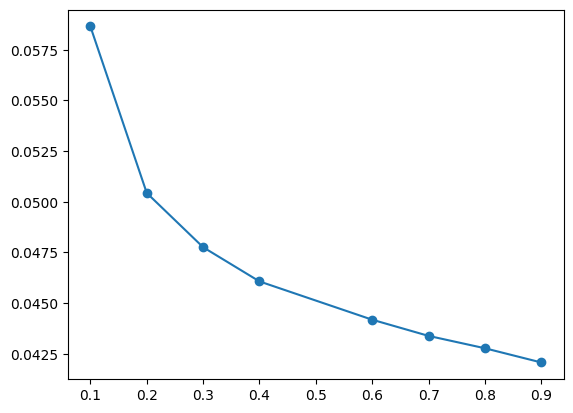

In [25]:
plt.plot(LAMBDA_VALUES, [-i for i in model_pens], marker='o')
true = pd.read_csv('nk_penalty_plots/nk_penalty_data.csv')
plt.plot(LAMBDA_VALUES, [-i for i in true['Average Penalty']], marker='x')

# Reacher

In [28]:
AGENT_PATH = "ppo_reacher_weight_1.zip"
VEC_ENV_FILE = "vec_normalize_reacher_weight_1.pkl"
AGENT_NAME = "single_agent_eval"
ENV_NAME = 'Reacher-v4'
NUM_EVAL_EPISODES = 10
LAMBDA_VALUES = [2,3,4]
device = "cuda:0"

In [29]:
import gymnasium as gym
import numpy as np
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
import matplotlib.pyplot as plt

class ReacherRewardWrapper(gym.Wrapper):
    def __init__(self, env, control_cost_weight=1.0):
        super().__init__(env)
        self.control_cost_weight = control_cost_weight

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        reward_dist = info['reward_dist']
        reward_ctrl = info['reward_ctrl']
        new_reward = reward_dist + self.control_cost_weight * reward_ctrl
        return obs, new_reward, terminated, truncated, info

In [73]:
# Activation class
class Swish(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x: Tensor) -> Tensor: 
        return torch.sigmoid(x) * x

# Model class
class MLP(nn.Module):
    def __init__(self, input_dim: int = 2, time_dim: int = 1, hidden_dim: int = 128, cond_dim: int = 1):
        super().__init__()
        
        self.input_dim = input_dim
        self.time_dim = time_dim
        self.hidden_dim = hidden_dim
        self.cond_dim = cond_dim

        self.main = nn.Sequential(
            nn.Linear(input_dim+time_dim+cond_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, input_dim),
            )
    

    def forward(self, x: Tensor, t: Tensor, cond: Tensor) -> Tensor:
        sz = x.size()
        x = x.reshape(-1, self.input_dim)
        t = t.reshape(-1, self.time_dim).float()
        cond = cond.reshape(-1, self.cond_dim).float()

        t = t.reshape(-1, 1).expand(x.shape[0], 1)
        h = torch.cat([x, t, cond], dim=1)
        output = self.main(h)
        
        return output.reshape(*sz)

class WrappedModel(ModelWrapper):
    def forward(self, x: torch.Tensor, t: torch.Tensor, cond: torch.Tensor, **extras):
        return self.model(x, t, cond)

In [30]:
def evaluate_lambda(model, vec_env_file, lambda_val, pushforward, pushforward_model=None):
    """Evaluate the agent with a specific lambda and pushforward"""
    def make_reacher_env():
        env = gym.make("Reacher-v4")
        env = ReacherRewardWrapper(env, control_cost_weight=lambda_val)
        return env

    env = VecNormalize.load(vec_env_file, DummyVecEnv([make_reacher_env]))
    env.training = False
    overall_average_penalties = []
    episode_rewards = []
    actions = []
    modified_actions = []
    
    for episode_num in range(NUM_EVAL_EPISODES):
        env.seed(episode_num)
        initial_obs_for_episode = env.reset()
        obs = initial_obs_for_episode
        done = False
        penalties_this_episode = []
        episode_reward = 0
        episode_steps = 0

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            modified_action = pushforward(action, obs, lambda_val, pushforward_model)
            actions.append(action)
            modified_actions.append(modified_action)
            next_obs, reward, done_array, info = env.step(modified_action)
            penalty = info[0]['reward_ctrl']
            penalties_this_episode.append(penalty)
            episode_reward += reward[0] 
            obs = next_obs
            done = done_array[0]
            episode_steps += 1
        
        avg_penalty_for_this_episode = np.mean(penalties_this_episode)
        overall_average_penalties.append(avg_penalty_for_this_episode)
        episode_rewards.append(episode_reward)

    env.close()
    final_avg_nk_penalty = np.mean(overall_average_penalties)
    std_dev_nk_penalty = np.std(overall_average_penalties)
    final_avg_reward = np.mean(episode_rewards)
    return final_avg_nk_penalty, std_dev_nk_penalty, final_avg_reward

In [40]:
ppo_model = PPO.load(AGENT_PATH)

/home/azureuser/miniconda/envs/hti_env/lib/python3.10/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


In [75]:
def null_pushforward(action, obs, lambda_val, pushforward_model=None):
    """
    A null pushforward function that returns the action unchanged.
    This is used when no pushforward is needed.
    """
    return action

In [76]:
def naive_pushforward(action, obs, lambda_val, pushforward_model):
    """
    Uses the trained naive model to push actions forward to target lambda, where naive model can take in any lamda for a given action, obs pair.
    """
    if lambda_val <= 1:
        return action
    naive_action = pushforward_model(torch.tensor(action, device=device), 
                                     torch.tensor(lambda_val, device=device), 
                                     torch.tensor(obs, device=device)).cpu().detach().numpy()

    return naive_action

In [92]:
def flow_pushforward(action, obs, lambda_val, pushforward_model):
    """
    Uses the trained CFM model to push actions forward to target lambda.
    """
    # scale lambda_val into [0,1], where min is 2 and max is 5
    time_point = (lambda_val - 2) / (5 - 2)
    if time_point <= 0:
        return action

    step_size = 0.05
    solver = ODESolver(velocity_model=pushforward_model)
    modified_action = solver.sample(
        time_grid=torch.tensor([0, time_point], device=device), 
        x_init=torch.tensor([action], device=device), 
        cond=torch.tensor([obs], device=device), 
        method='midpoint', 
        step_size=step_size, 
        return_intermediates=True
    )[-1][0].cpu().numpy()

    #print(action, modified_action)
    return modified_action

In [78]:
class Swish(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x: Tensor) -> Tensor: 
        return torch.sigmoid(x) * x

# Model class with FiLM conditioning - ONLY on first layer
class FiLMMLP(nn.Module):
    def __init__(self, input_dim: int = 2, time_dim: int = 1, hidden_dim: int = 128, cond_dim: int = 7):
        super().__init__()
        
        self.input_dim = input_dim
        self.time_dim = time_dim
        self.hidden_dim = hidden_dim
        self.cond_dim = cond_dim
        
        # Main network layers
        self.input_layer = nn.Linear(input_dim + time_dim, hidden_dim)
        self.hidden_layers = nn.ModuleList([
            nn.Linear(hidden_dim, hidden_dim) for _ in range(3)
        ])
        self.output_layer = nn.Linear(hidden_dim, input_dim)
        
        self.activation = Swish()
        
        # FiLM generator network - ONLY for first layer
        self.film_generator = nn.Sequential(
            nn.Linear(cond_dim, hidden_dim),
            self.activation,
            nn.Linear(hidden_dim, hidden_dim * 2)  # Only gamma and beta for first layer
        )
        
    def forward(self, x: Tensor, t: Tensor, cond: Tensor) -> Tensor:
        sz = x.size()
        x = x.reshape(-1, self.input_dim)
        t = t.reshape(-1, self.time_dim).float()
        cond = cond.reshape(-1, self.cond_dim).float()

        # Expand time to match batch size
        t = t.reshape(-1, 1).expand(x.shape[0], 1)
        
        # Generate FiLM parameters from condition - only for first layer
        film_params = self.film_generator(cond)
        gamma = film_params[:, :self.hidden_dim]  # First half
        beta = film_params[:, self.hidden_dim:]   # Second half

        # Main forward pass
        h = torch.cat([x, t], dim=1)
        
        # Input layer with FiLM conditioning
        h = self.input_layer(h)
        h = gamma * h + beta  # Apply FiLM only here
        h = self.activation(h)
        
        # Hidden layers WITHOUT FiLM conditioning
        for layer in self.hidden_layers:
            h = layer(h)
            h = self.activation(h)
            
        # Output layer
        output = self.output_layer(h)
        
        return output.reshape(*sz)

In [68]:
AGENT_PATH = f"ppo_reacher_weight_1.zip"
VEC_ENV_FILE = f"vec_normalize_reacher_weight_1.pkl"
ppo_model = PPO.load(AGENT_PATH)

pens_naive = []
rewards_naive = []

for j in range(5):
    print(f"Loading naive model {j} weights...")
    pens_naive_j = []
    rewards_naive_j = []
    naive_model = FiLMMLP(input_dim=2, time_dim=1, hidden_dim=64, cond_dim=11).to(device)
    naive_model_weights = torch.load(f'../rebuttal_baselines/3_5/naive_reacher_FiLM_model_{j}_test.pt')
    naive_model.load_state_dict(naive_model_weights)

    for i in LAMBDA_VALUES:
        eval = evaluate_lambda(ppo_model, VEC_ENV_FILE, i, naive_pushforward, naive_model)
        rew = eval[2]
        print(f"Reward for lambda {i}: {rew}")
        pen = eval[0]
        print(f"Penalty for lambda {i}: {pen}")
        rewards_naive_j.append(rew)
        pens_naive_j.append(pen)
        
    pens_naive.append(pens_naive_j)
    rewards_naive.append(rewards_naive_j)
    print(np.mean(rewards_naive_j))

/home/azureuser/miniconda/envs/hti_env/lib/python3.10/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


Loading naive model 0 weights...
Reward for lambda 4: -8.33445144854486
Penalty for lambda 4: -0.005246697459369898
-8.33445144854486
Loading naive model 1 weights...
Reward for lambda 4: -7.785508699622005
Penalty for lambda 4: -0.0061157625168561935
-7.785508699622005
Loading naive model 2 weights...
Reward for lambda 4: -8.495763331092894
Penalty for lambda 4: -0.006405779160559177
-8.495763331092894
Loading naive model 3 weights...
Reward for lambda 4: -8.15511463349685
Penalty for lambda 4: -0.006517691072076559
-8.15511463349685
Loading naive model 4 weights...
Reward for lambda 4: -7.022638967679813
Penalty for lambda 4: -0.004580572713166475
-7.022638967679813


In [69]:
print_results([np.mean(i) for i in rewards_naive], "Naive Rewards")

Naive Rewards: -7.959 ± 0.460


In [63]:
(-4.82 - 6.993 * 2) / 3

-6.268666666666667

In [70]:
(-4.82 - 5.66 - 7.959) / 3

-6.146333333333334

In [91]:
AGENT_PATH = f"ppo_reacher_weight_2.zip"
VEC_ENV_FILE = f"vec_normalize_reacher_weight_2.pkl"
ppo_model = PPO.load(AGENT_PATH)

pens_flow = []
rewards_flow = []

for j in range(5):
    print(f"Loading CFM model {j} weights...")
    pens_flow_j = []
    rewards_flow_j = []
    cfm_model = FiLMMLP(input_dim=2, time_dim=1, cond_dim=11, hidden_dim=64).to(device) 
    cfm_model = WrappedModel(cfm_model)
    cfm_weights = torch.load(f'../rebuttal_baselines/2_5/cfm_reacher_FiLM_model_{j}_64hdim.pt')
    cfm_model.load_state_dict(cfm_weights)

    for i in LAMBDA_VALUES:
        eval = evaluate_lambda(ppo_model, VEC_ENV_FILE, i, flow_pushforward, cfm_model)
        pen = eval[0]
        rew = eval[2]
        print(f"Reward for lambda {i}: {rew}")
        print(f"Penalty for lambda {i}: {pen}")
        pens_flow_j.append(pen)
        rewards_flow_j.append(rew)
        
    pens_flow.append(pens_flow_j)
    rewards_flow.append(rewards_flow_j)
    print(np.mean(rewards_flow_j))

Loading CFM model 0 weights...
[[0.14316706 0.23496982]] [[0.11485144 0.18946066]]
[[0.1084675  0.20947587]] [[0.08754496 0.17194024]]
[[0.08171722 0.18142869]] [[0.064599   0.15145028]]
[[0.05426541 0.15790275]] [[0.04217604 0.13459815]]
[[0.03282149 0.13926277]] [[0.0254619 0.121463 ]]
[[0.02195344 0.12397784]] [[0.01784962 0.1108555 ]]
[[0.01818179 0.10981151]] [[0.01578468 0.1009936 ]]
[[0.01586637 0.09489613]] [[0.0139679  0.09017707]]
[[0.01101133 0.07834068]] [[0.00909834 0.07747393]]
[[0.00243682 0.06077312]] [[0.00063841 0.06338496]]
[[-0.00854941  0.04422354]] [[-0.00985819  0.04982382]]
[[-0.01976255  0.03074376]] [[-0.02024952  0.03879139]]
[[-0.02962025  0.0211327 ]] [[-0.02906439  0.03110515]]
[[-0.03747388  0.01491764]] [[-0.03576058  0.02634287]]
[[-0.04328158  0.01100752]] [[-0.04039688  0.0234667 ]]
[[-0.04726596  0.00825911]] [[-0.04329197  0.02138543]]
[[-0.0497136   0.00576741]] [[-0.04479912  0.01924605]]
[[-0.05087882  0.00294489]] [[-0.04517712  0.01650954]]
[[-

KeyboardInterrupt: 

In [89]:
print_results([np.mean(i) for i in rewards_flow], "Flow Rewards")

Flow Rewards: -6.069 ± 0.114


In [86]:
(-6.069 * 2 - 4.82) / 3

-5.652666666666666

In [93]:
(-6.175 * 2 - 4.82) / 3

-5.723333333333334

In [91]:
pens_real = []
rewards_real = []
for i in LAMBDA_VALUES:
    AGENT_PATH = f"ppo_reacher_weight_{i}.zip"
    VEC_ENV_FILE = f"vec_normalize_reacher_weight_{i}.pkl"
    ppo_model = PPO.load(AGENT_PATH)
    eval = evaluate_lambda(ppo_model, VEC_ENV_FILE, i, null_pushforward)
    pen = eval[0]
    rew = eval[2]
    print(f"Reward for lambda {i}: {rew}")
    rewards_real.append(rew)
    pens_real.append(pen)

Reward for lambda 2: -5.246425840888987
Reward for lambda 3: -4.555084488167195
Reward for lambda 4: -5.769566668870393


In [92]:
np.mean(rewards_real)

-5.190358999308859

TypeError: bad operand type for unary -: 'list'

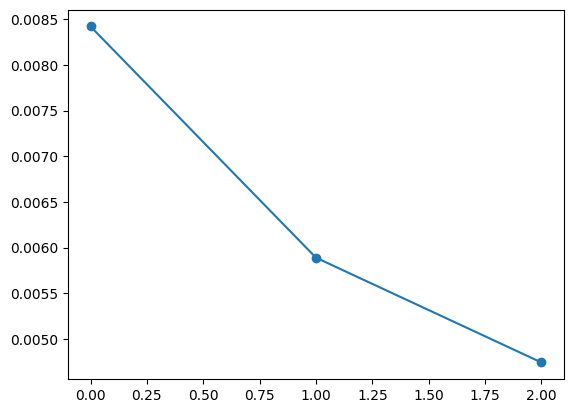

In [116]:
plt.plot([-i for i in pens_real], marker='o')
plt.plot([-i for i in pens_naive], marker='x')
plt.plot([-i for i in pens_flow], marker='^')

In [117]:
pens_naive

[[-0.010370498, -0.0062752324, -0.0051817643],
 [-0.008184357, -0.005462041, -0.004377269],
 [-0.01044236, -0.0058982307, -0.0046184743],
 [-0.011539935, -0.007041819, -0.0060263965],
 [-0.0067241113, -0.004372607, -0.0043934803]]

In [123]:
pens_flow

[[-0.015299508, -0.010188503, -0.0098188715],
 [-0.016403418, -0.010968242, -0.009280307],
 [-0.013714975, -0.011887917, -0.0071407394],
 [-0.012257378, -0.014578506, -0.008540181],
 [-0.018140156, -0.012385271, -0.008895611]]

In [126]:
np.mean(pens_naive, axis=0)

array([-0.00945225, -0.00580999, -0.00491948], dtype=float32)

In [124]:
pens_real

[-0.008421041, -0.0058888225, -0.00474109]

## Reacher — MFM (Metric Flow Matching) Pushforward

In [37]:
def mfm_pushforward(action, obs, lambda_val, pushforward_model):
    """
    Push actions forward using the MFM velocity field for Reacher.
    
    Lambda mapping:  base λ=1, final λ=5  →  time = (λ - 1) / (5 - 1)
    Uses ode_integrate_midpoint (pure torch, no torchdyn).
    """
    time_point = (lambda_val - 1) / (5 - 1)
    if time_point <= 0:
        return action

    x0 = torch.tensor(action, dtype=torch.float32, device=device)
    if x0.dim() == 1:
        x0 = x0.unsqueeze(0)
    cond_tensor = torch.tensor(obs, dtype=torch.float32, device=device)
    if cond_tensor.dim() == 1:
        cond_tensor = cond_tensor.unsqueeze(0)

    modified = ode_integrate_midpoint(
        pushforward_model, x0, cond_tensor, t_target=time_point, n_steps=50
    )
    modified_action = modified.cpu().numpy()
    return modified_action.reshape(action.shape)

In [38]:
# --- Evaluate MFM pushforward on Reacher — multi-checkpoint ---
LAMBDA_VALUES_MFM = [2, 3, 4]
NUM_EVAL_EPISODES = 10

AGENT_PATH_MFM = "ppo_reacher_weight_1.zip"
VEC_ENV_FILE_MFM = "vec_normalize_reacher_weight_1.pkl"
ppo_model_mfm = PPO.load(AGENT_PATH_MFM)

# Collect per-checkpoint results
all_ckpt_reacher_rewards = []
all_ckpt_reacher_penalties = []

for ci, ckpt_path in enumerate(MFM_REACHER_CKPTS):
    print(f"\n--- Reacher checkpoint {ci+1}/{len(MFM_REACHER_CKPTS)}: {ckpt_path.split('/')[-3]} ---")
    mfm_vel_net = load_mfm_vel_net(ckpt_path, dim=2, cond_dim=11, device=device)
    
    ckpt_rewards = []
    ckpt_penalties = []
    for lam in LAMBDA_VALUES_MFM:
        result = evaluate_lambda(
            ppo_model_mfm, VEC_ENV_FILE_MFM, lam,
            mfm_pushforward, mfm_vel_net,
        )
        pen, _, rew = result
        ckpt_rewards.append(rew)
        ckpt_penalties.append(pen)
    
    all_ckpt_reacher_rewards.append(np.mean(ckpt_rewards))
    print(f"Average reward for checkpoint {ci+1}: {np.mean(ckpt_rewards):.3f}")
    all_ckpt_reacher_penalties.append(np.mean(ckpt_penalties))
    del mfm_vel_net

print_results(all_ckpt_reacher_rewards, "MFM Reacher Rewards")

/home/azureuser/miniconda/envs/hti_env/lib/python3.10/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(



--- Reacher checkpoint 1/20: 20260225_103653_reacher_data_s0_aibkpofp ---


Average reward for checkpoint 1: -6.395

--- Reacher checkpoint 2/20: 20260225_103931_reacher_data_s1_u12t6zy3 ---
Average reward for checkpoint 2: -6.672

--- Reacher checkpoint 3/20: 20260225_104215_reacher_data_s2_goppej5h ---
Average reward for checkpoint 3: -6.162

--- Reacher checkpoint 4/20: 20260225_104450_reacher_data_s3_t4fkgiag ---
Average reward for checkpoint 4: -6.293

--- Reacher checkpoint 5/20: 20260225_104724_reacher_data_s4_tqsbdjyr ---
Average reward for checkpoint 5: -6.170

--- Reacher checkpoint 6/20: 20260225_112755_reacher_data_s5_silxd9z2 ---
Average reward for checkpoint 6: -6.438

--- Reacher checkpoint 7/20: 20260225_113041_reacher_data_s6_dtse2voa ---
Average reward for checkpoint 7: -6.619

--- Reacher checkpoint 8/20: 20260225_113322_reacher_data_s7_4ltt17w5 ---
Average reward for checkpoint 8: -6.606

--- Reacher checkpoint 9/20: 20260225_113606_reacher_data_s8_e72pp762 ---
Average reward for checkpoint 9: -6.593

--- Reacher checkpoint 10/20: 20260225_